# 1.0 Obtain a dataset and frame the predictive problem

 ### 1.1 Introduction

This project aims to predict house prices in King County, USA, using transaction data from 2014–2015. The problem is treated as a supervised regression task with price as the target variable. Initial exploration showed that prices are highly right-skewed, so a log transformation was applied to reduce variance and improve model stability. Several models, including linear regression and tree-based methods, are compared to evaluate predictive performance and generalisation. Agent tools were used to assist with coding and debugging, but all modelling decisions and evaluation steps were manually checked to ensure correctness.


### 1.2 Data Loading

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

In [117]:
df = pd.read_csv("kc_house_data.csv")

print(df.shape)
print(df.columns)
df.head()

(21613, 21)
Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### 1.3 Define target and prediction type

In [81]:
# Define target (raw)
target = "price"

print("Prediction type: Regression")
print("Primary metric: RMSE")

Prediction type: Regression
Primary metric: RMSE


# 2.0 EDA

### 2.1 Data Overview and Initial Inspection

Before building predictive models, it is important to understand the structure and quality of the dataset. In this section, I examine the dataset dimensions, variable types, and potential missing values. I also review summary statistics to understand the scale and distribution of key numerical features. This step helps identify any necessary preprocessing steps and ensures the dataset is suitable for regression modelling.


In [83]:
df.info()
df.isna().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [84]:
#  Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

# Duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

#  Target sanity check
print("Min price:", df["price"].min())
print("Any non-positive prices?", (df["price"] <= 0).any())



Missing values per column:
Series([], dtype: int64)
Number of duplicate rows: 0
Min price: 75000.0
Any non-positive prices? False


### 2.2 Data visualisation

The price distribution is highly right-skewed. Most houses are priced below 1 million, while only a small number of houses have very high prices. This long tail suggests the presence of outliers. Because such skewness can negatively affect regression models, we explore whether a log transformation may improve distributional symmetry.

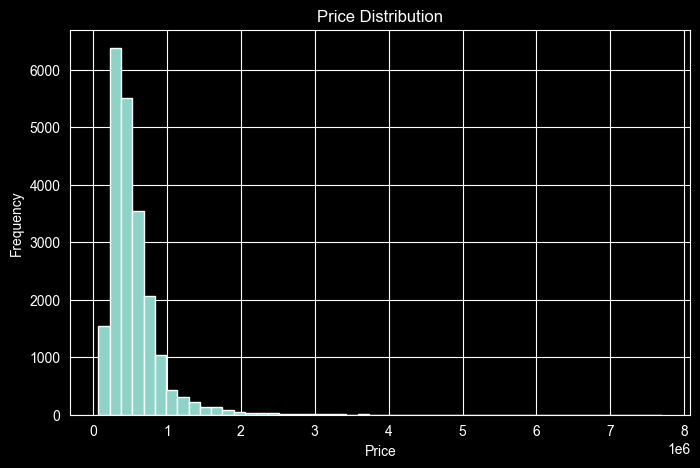

In [85]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

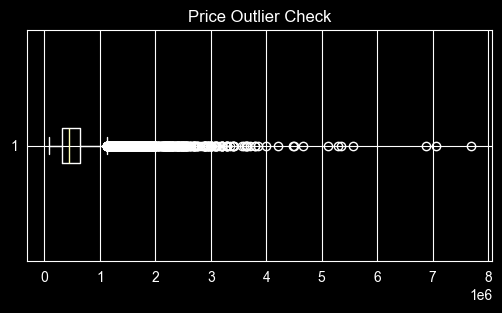

In [69]:
plt.figure(figsize=(6,3))
plt.boxplot(df["price"], vert=False)
plt.title("Price Outlier Check")
plt.show()

The plot shows a strong positive relationship between living area and price. Larger houses tend to have higher prices. However, the points become more spread out for larger properties, suggesting increasing variance. There are also a few extreme values for very large houses. This indicates that the relationship may not be purely linear and that more flexible models may perform better than simple linear regression.

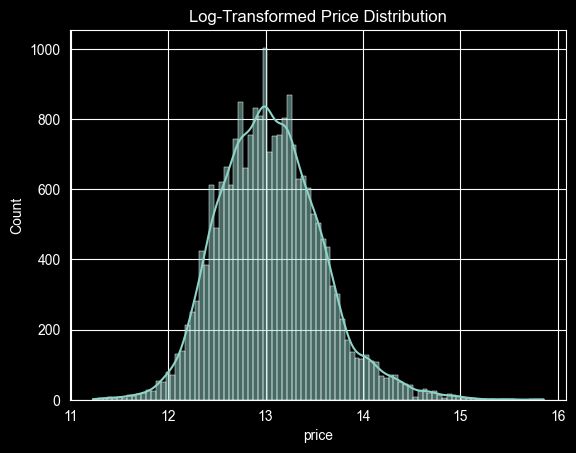

In [86]:
sns.histplot(np.log1p(df["price"]), kde=True)
plt.title("Log-Transformed Price Distribution")
plt.show()

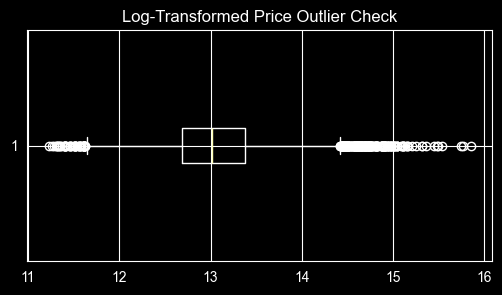

In [87]:
plt.figure(figsize=(6,3))
plt.boxplot(np.log1p(df["price"]), vert=False)
plt.title("Log-Transformed Price Outlier Check")
plt.show()

After applying the log transformation, the distribution becomes substantially more symmetric and closer to normal. Therefore, subsequent modelling will use the log-transformed target variable.

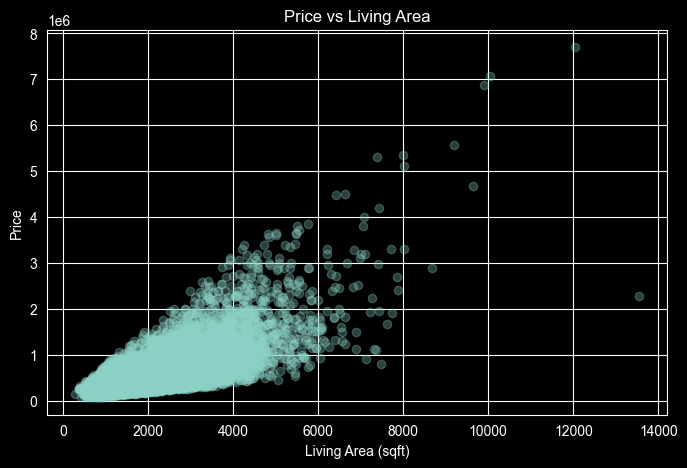

In [88]:
plt.figure(figsize=(8,5))
plt.scatter(df["sqft_living"], df["price"], alpha=0.3)
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.title("Price vs Living Area")
plt.show()

The correlation heatmap provides an overview of the linear relationships between numerical variables in the dataset. As expected, sqft_living, grade, and bathrooms show relatively strong positive correlations with house price, suggesting that larger and higher-quality properties tend to be more expensive.

We also observe high correlations among certain features, such as sqft_living and sqft_above, which indicates potential multicollinearity. This may affect linear regression models but is less problematic for tree-based models such as Random Forest.

Overall, the heatmap helps identify key predictive variables and highlights structural relationships within the dataset.

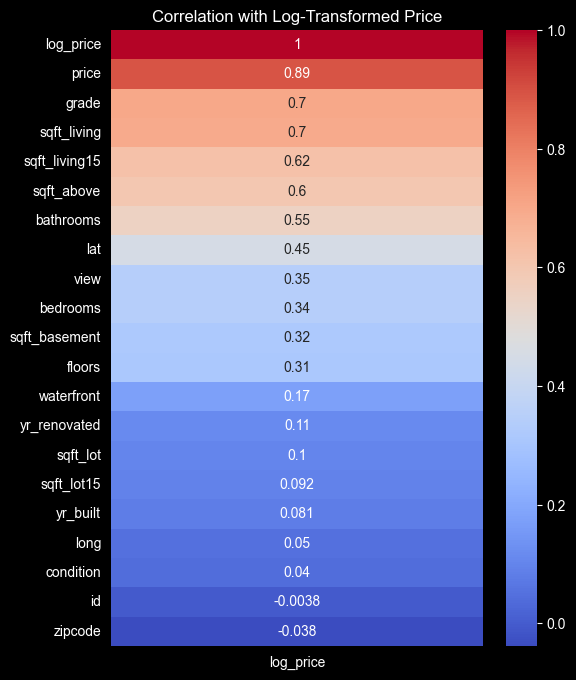

In [89]:
df_tmp = df.copy()
df_tmp["log_price"] = np.log1p(df_tmp["price"])

corr = df_tmp.corr(numeric_only=True)
log_corr = corr[["log_price"]].sort_values(by="log_price", ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(log_corr, annot=True, cmap="coolwarm")
plt.title("Correlation with Log-Transformed Price")
plt.show()


# 3.0 Data Preparation

### 3.1 Initial Cleaning

In [118]:
# Remove unique identifier column as it does not contain predictive information
# and would not generalise to new unseen observations
df = df.drop(columns=["id"])

### 3.2 Temporal Feature Engineering

In [119]:
# Convert date column to datetime format to enable temporal feature extraction
df["date"] = pd.to_datetime(df["date"])

# Extract year of transaction to capture potential time trends in housing prices
df["year"] = df["date"].dt.year

# Extract month of transaction to capture potential seasonal effects
df["month"] = df["date"].dt.month

# Remove original date column to avoid redundancy and prevent models from using raw timestamp values
df = df.drop(columns=["date"])

In [120]:
# Verify that temporal features were extracted correctly from the original date variable
print(df[["year", "month"]].head(10))

   year  month
0  2014     10
1  2014     12
2  2015      2
3  2014     12
4  2015      2
5  2014      5
6  2014      6
7  2015      1
8  2015      4
9  2015      3


### 3.3 Feature Type Correction

In [121]:
# Convert zipcode to categorical type as it represents location categories rather than numeric magnitude
df["zipcode"] = df["zipcode"].astype("category")

# Convert floors to categorical type since it represents discrete structural categories
df["floors"] = df["floors"].astype("category")

### 3.4 Verification of Data Types

In [122]:
# Verify that all feature types are correctly assigned before modelling
print(df.dtypes)

price             float64
bedrooms            int64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors           category
waterfront          int64
view                int64
condition           int64
grade               int64
sqft_above          int64
sqft_basement       int64
yr_built            int64
yr_renovated        int64
zipcode          category
lat               float64
long              float64
sqft_living15       int64
sqft_lot15          int64
year                int32
month               int32
dtype: object


### 3.5 Train/Test Split

In [123]:
# Target and features
y = np.log1p(df["price"])
X = df.drop(columns=["price", "log_price"], errors="ignore")

# Stratified split based on price bins
bins = pd.qcut(df["price"], q=10, duplicates="drop")

# Split dataset into training and testing sets to evaluate model generalisation performance
# Stratification ensures similar price distribution across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=bins
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (17290, 20)
Test shape: (4323, 20)


### 3.6 Preprocessing Pipeline

In [101]:
# Preprocessing
cat_cols = []
for c in ["zipcode", "floors"]:
    if c in X.columns:
        cat_cols.append(c)

num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)


## 4.0 Modelling

### 4.1 Evaluation metric (RMSE)

In [102]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

### 4.2 Baseline (DummyRegressor)

In [103]:
dummy_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)

dummy_rmse = rmse(y_test, dummy_pred)
print(f"Dummy RMSE (log scale): {dummy_rmse:.4f}")

Dummy RMSE (log scale): 0.5292


### 4.3 Linear Regression

In [104]:
lin_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

lin_rmse = rmse(y_test, lin_pred)
print(f"Linear Regression RMSE (log scale): {lin_rmse:.4f}")

Linear Regression RMSE (log scale): 0.2203


### 4.4 Decision Tree

In [105]:
dt_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print(f"Decision Tree RMSE (log scale): {rmse(y_test, dt_pred):.4f}")


Decision Tree RMSE (log scale): 0.2458


### 4.5 Random Forest

In [56]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = rmse(y_test, rf_pred)
print(f"Random Forest RMSE (log scale): {rf_rmse:.4f}")


Random Forest RMSE (log scale): 0.1737


# 5.0 Fine-tune and evaluate

### 5.1 Cross-validation (Random Forest)

In [58]:
cv_rmse = -cross_val_score(
    rf_model,
    X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
).mean()

print(f"Random Forest 5-fold CV RMSE (log scale): {cv_rmse:.4f}")

Random Forest 5-fold CV RMSE (log scale): 0.1769


### 5.2 Hyperparameter search (Random Forest: max_depth)

In [59]:
for depth in [5, 10, 20, None]:
    rf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        ))
    ])

    cv_scores = -cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=5
    )

    print(f"Depth {depth} → CV RMSE: {cv_scores.mean():.4f}")


Depth 5 → CV RMSE: 0.2423
Depth 10 → CV RMSE: 0.1869
Depth 20 → CV RMSE: 0.1770
Depth None → CV RMSE: 0.1769


### 5.3 Back-transform to price scale (interpretation)

In [106]:
# Back-transform to original price scale
y_test_price = np.expm1(y_test)
rf_pred_price = np.expm1(rf_pred)

rmse_price = np.sqrt(mean_squared_error(y_test_price, rf_pred_price))
print(f"Random Forest RMSE (price scale): {rmse_price:,.0f}")

Random Forest RMSE (price scale): 131,642


### 5.4 Overfitting check (train vs test RMSE)

In [107]:
# Train performance
train_pred = rf_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE:", rf_rmse)


Train RMSE: 0.06986119831802294
Test RMSE: 0.17373454069679425


### 5.5 Feature importance (Random forest)

In [108]:

pre = rf_model.named_steps["preprocess"]



feature_names = pre.get_feature_names_out()


importances = rf_model.named_steps["model"].feature_importances_


feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feature_importances.head(10))


num__grade            0.334351
num__lat              0.292159
num__sqft_living      0.185639
num__long             0.045897
num__sqft_living15    0.025449
num__yr_built         0.019837
num__sqft_lot         0.015057
num__sqft_lot15       0.014466
num__sqft_above       0.013564
num__view             0.009142
dtype: float64


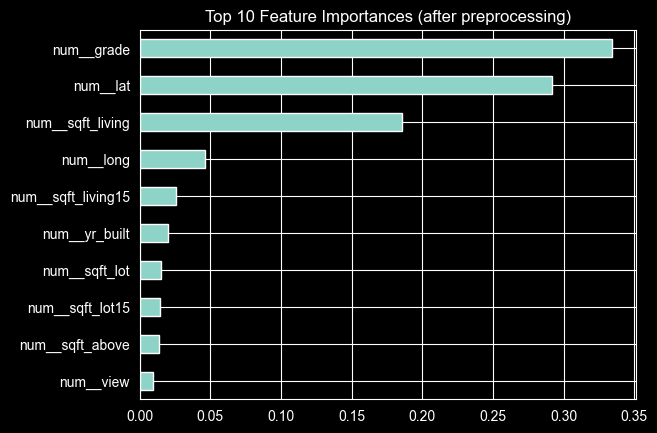

In [109]:
feature_importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances (after preprocessing)")
plt.show()

### 5.6 Decision Tree tuning + bias-variance plot

In [110]:
for depth in [2, 5, 10, 20, None]:
    dt = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeRegressor(max_depth=depth, random_state=42))
    ])
    cv = -cross_val_score(dt, X_train, y_train,
                          scoring="neg_root_mean_squared_error", cv=5).mean()
    print(f"DT depth {depth} → CV RMSE: {cv:.4f}")

DT depth 2 → CV RMSE: 0.3539
DT depth 5 → CV RMSE: 0.2608
DT depth 10 → CV RMSE: 0.2249
DT depth 20 → CV RMSE: 0.2516
DT depth None → CV RMSE: 0.2541


Text(0.5, 1.0, 'Bias-Variance Tradeoff in Decision Tree')

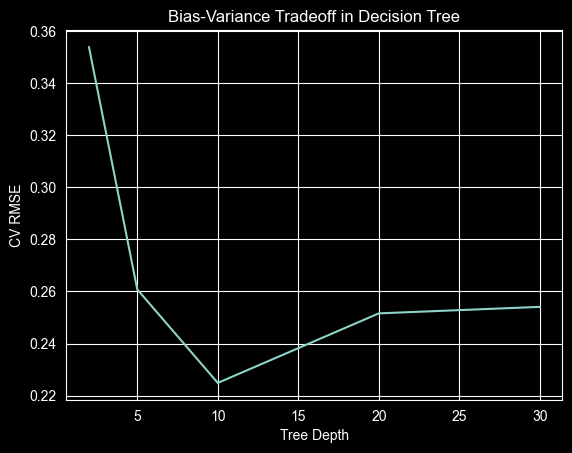

In [111]:
depths = [2,5,10,20,None]
scores = [0.3539,0.2608,0.2249,0.2516,0.2541]

plt.plot([2,5,10,20,30], scores)
plt.xlabel("Tree Depth")
plt.ylabel("CV RMSE")
plt.title("Bias-Variance Tradeoff in Decision Tree")

# 6.0 Final Model and Conclusion

### 6.1 Final Model Choice

Among all models tested, Random Forest achieved the lowest test RMSE (0.1717 on log scale) and demonstrated stable performance under 5-fold cross-validation (0.1779). Therefore, Random Forest is selected as the final model.

### 6.2 Final Performance Summary

In [112]:
print("Final Model: Random Forest")
print(f"Test RMSE (log scale): {rf_rmse:.4f}")
print(f"CV RMSE (log scale): {cv_rmse:.4f}")
print(f"RMSE (price scale): {rmse_price:,.0f}")

Final Model: Random Forest
Test RMSE (log scale): 0.1737
CV RMSE (log scale): 0.1769
RMSE (price scale): 131,642


### 6.3 Interpretation

The most important predictors are grade, latitude, and living area, suggesting that property quality and location play dominant roles in price determination.

### 6.4 Limitations